In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [2]:
df = pd.read_csv('chatgpt_reviews_clean.csv')
print('Shape:', df.shape)
df.head()

Shape: (500, 13)


,review,rating,helpful_votes,platform,language,location,version,verified_purchase,date_clean,review_length_clean,review_clean,clean_token_count,sentiment
0,"Not satisfied, many bugs and issues.",1,80,Amazon,zh,Kenya,2.1.4,No,NaN,36,not satisfy many bug issue,5,Negative
1,Amazing quality and user-friendly interface.,5,180,Flipkart,zh,France,1.2.3,No,NaN,44,amaze quality user friendly interface,5,Positive
2,"Terrible experience, needs major improvements.",2,154,Flipkart,pt,USA,1.2.3,No,NaN,46,terrible experience need major improvement,5,Negative
3,Poor performance and not user-friendly.,1,96,Amazon,es,Qatar,2.1.4,Yes,NaN,39,poor performance not user friendly,5,Negative
4,"Not satisfied, many bugs and issues.",2,139,Website,ar,Kenya,2.1.4,No,NaN,36,not satisfy many bug issue,5,Negative


Feature Engineering

In [3]:
text_sentiment_map = df.groupby('review_clean')['sentiment'].agg(lambda x: x.unique())
print(text_sentiment_map)
assert (text_sentiment_map.apply(len) == 1).all(), "Error: A review_clean text maps to more than one sentiment!"

review_clean
amaze quality user friendly interface                 [Positive]
app okay job reasonably well                           [Neutral]
average experience feature could improve               [Neutral]
decent app neither good nor bad                        [Neutral]
disappoint experience app crash often                 [Negative]
excellent app easy use extremely helpful              [Positive]
great experience smooth performance useful feature    [Positive]
highly satisfy app work exactly expect                [Positive]
not bad update need better performance                 [Neutral]
not satisfy many bug issue                            [Negative]
poor performance not user friendly                    [Negative]
reliable worth use regularly                          [Positive]
terrible experience need major improvement            [Negative]
waste time not meet expectation                       [Negative]
work fine room improvement                             [Neutral]
Name: sentim

Leakage safe train/test

In [4]:
from sklearn.model_selection import train_test_split

unique_texts = text_sentiment_map.index.to_numpy()
unique_labels = text_sentiment_map.apply(lambda x: x[0]).to_numpy()

train_texts, test_texts = train_test_split(
    unique_texts,
    test_size=0.2,
    stratify=unique_labels,
    random_state=42
)

train_df = df[df['review_clean'].isin(train_texts)].copy()
test_df  = df[df['review_clean'].isin(test_texts)].copy()

y_train = train_df['sentiment']
y_test  = test_df['sentiment']

print(f"Unique texts -> train: {len(train_texts)}, test: {len(test_texts)}")
print(f"Rows -> train: {len(train_df)}, test: {len(test_df)}")
print()
print("Train sentiment balance:"); print(train_df['sentiment'].value_counts())
print()
print("Test sentiment balance:"); print(test_df['sentiment'].value_counts())

Unique texts -> train: 12, test: 3
Rows -> train: 397, test: 103

Train sentiment balance:
sentiment
Positive    161
Negative    154
Neutral      82
Name: count, dtype: int64

Test sentiment balance:
sentiment
Negative    41
Positive    39
Neutral     23
Name: count, dtype: int64


TF-IDF


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(train_df['review_clean'])
X_test_tfidf  = tfidf.transform(test_df['review_clean'])

print("TF-IDF matrix shapes:", X_train_tfidf.shape, X_test_tfidf.shape)

TF-IDF matrix shapes: (397, 99) (103, 99)


In [6]:
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

scaler = StandardScaler()
train_numeric = scaler.fit_transform(train_df[['review_length_clean', 'clean_token_count']])
test_numeric  = scaler.transform(test_df[['review_length_clean', 'clean_token_count']])

X_train = hstack([X_train_tfidf, train_numeric])
X_test  = hstack([X_test_tfidf, test_numeric])

print("Combined feature matrix shapes:", X_train.shape, X_test.shape)

Combined feature matrix shapes: (397, 101) (103, 101)


LSTM 

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)

MAX_WORDS = 2000
MAX_LEN = 30

keras_tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
keras_tokenizer.fit_on_texts(train_df['review_clean'])

X_train_lstm = pad_sequences(keras_tokenizer.texts_to_sequences(train_df['review_clean']), maxlen=MAX_LEN, padding='post')
X_test_lstm  = pad_sequences(keras_tokenizer.texts_to_sequences(test_df['review_clean']), maxlen=MAX_LEN, padding='post')

label_to_idx = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
idx_to_label = {v: k for k, v in label_to_idx.items()}

y_train_cat = to_categorical(train_df['sentiment'].map(label_to_idx).values, num_classes=3)
y_test_cat  = to_categorical(test_df['sentiment'].map(label_to_idx).values, num_classes=3)

print(f"Vocabulary learned from training text: {len(keras_tokenizer.word_index)} words")
print(f"LSTM input shapes: {X_train_lstm.shape}, {X_test_lstm.shape}")

Vocabulary learned from training text: 50 words
LSTM input shapes: (397, 30), (103, 30)


Train ML models

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Linear SVM': LinearSVC(random_state=42, max_iter=5000),
}

trained_models = {}
for name, model in models.items():
    X_tr = X_train_tfidf if name == 'Multinomial Naive Bayes' else X_train
    model.fit(X_tr, y_train)
    trained_models[name] = model
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Multinomial Naive Bayes
Trained: Random Forest
Trained: Linear SVM


Train DL model

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D

lstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=32, input_length=MAX_LEN),
    SpatialDropout1D(0.3),
    LSTM(32, dropout=0.3, recurrent_dropout=0.3),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax'),
])
lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.summary()

C:\Users\yogap\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = lstm_model.fit(
    X_train_lstm, y_train_cat,
    validation_data=(X_test_lstm, y_test_cat),
    epochs=15, batch_size=16, verbose=1,
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 88ms/step - accuracy: 0.3728 - loss: 1.0832 - val_accuracy: 0.3786 - val_loss: 1.0716
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3753 - loss: 1.0616 - val_accuracy: 0.3786 - val_loss: 1.0761
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4081 - loss: 1.0588 - val_accuracy: 0.3786 - val_loss: 1.0728
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4584 - loss: 1.0345 - val_accuracy: 0.0000e+00 - val_loss: 1.1133
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7154 - loss: 0.6948 - val_accuracy: 0.3981 - val_loss: 2.6949
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7909 - loss: 0.4364 - val_accuracy: 0.3981 - val_loss: 3.6154
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7935 - loss: 0.3995 - val_accuracy: 0.3981 - val_loss: 4.0290
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7909 - loss: 0.4034 - val_accuracy: 0.398

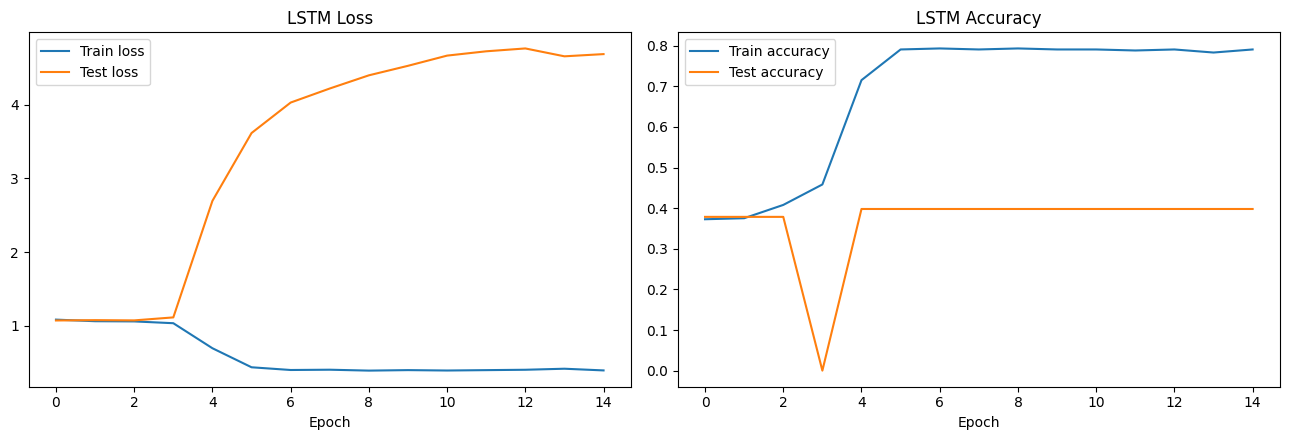

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history.history['loss'], label='Train loss')
axes[0].plot(history.history['val_loss'], label='Test loss')
axes[0].set_title('LSTM Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='Train accuracy')
axes[1].plot(history.history['val_accuracy'], label='Test accuracy')
axes[1].set_title('LSTM Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()

Evaluation

In [12]:
predictions = {}

for name, model in trained_models.items():
    X_te = X_test_tfidf if name == 'Multinomial Naive Bayes' else X_test
    predictions[name] = model.predict(X_te)

lstm_probs = lstm_model.predict(X_test_lstm, verbose=0)
predictions['LSTM'] = pd.Series(lstm_probs.argmax(axis=1)).map(idx_to_label).values

In [13]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

results = []
for name, preds in predictions.items():
    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average='macro', zero_division=0)
    results.append({'Model': name, 'Accuracy': acc, 'Precision (macro)': prec, 'Recall (macro)': rec, 'F1 (macro)': f1})

results_df = pd.DataFrame(results).sort_values('F1 (macro)', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,Logistic Regression,0.398058,0.333333,0.333333,0.333333
1,Linear SVM,0.398058,0.333333,0.333333,0.333333
2,LSTM,0.398058,0.170833,0.333333,0.225895
3,Random Forest,0.000000,0.000000,0.000000,0.000000
4,Multinomial Naive Bayes,0.000000,0.000000,0.000000,0.000000


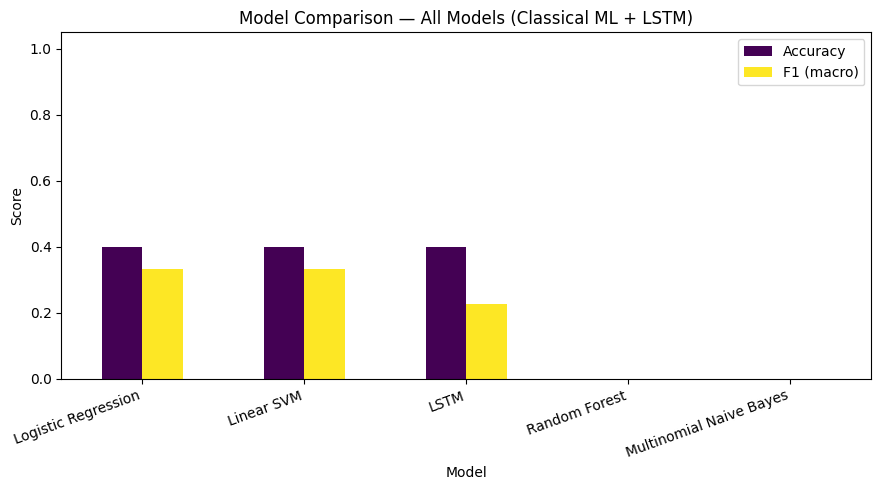

In [14]:
results_df.set_index('Model')[['Accuracy', 'F1 (macro)']].plot(kind='bar', figsize=(9, 5), colormap='viridis')
plt.title('Model Comparison — All Models (Classical ML + LSTM)')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

Classification report

In [15]:
from sklearn.metrics import classification_report

labels_order = ['Negative', 'Neutral', 'Positive']
for name, preds in predictions.items():
    print(f"--- {name} ---")
    print(classification_report(y_test, preds, target_names=labels_order, zero_division=0))
    print()

--- Logistic Regression ---
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        41
     Neutral       0.00      0.00      0.00        23
    Positive       0.00      0.00      0.00        39

    accuracy                           0.40       103
   macro avg       0.33      0.33      0.33       103
weighted avg       0.40      0.40      0.40       103


--- Multinomial Naive Bayes ---
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00      41.0
     Neutral       0.00      0.00      0.00      23.0
    Positive       0.00      0.00      0.00      39.0

    accuracy                           0.00     103.0
   macro avg       0.00      0.00      0.00     103.0
weighted avg       0.00      0.00      0.00     103.0


--- Random Forest ---
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00      41.0
     Neutral       0.00      0.00      0.00  

In [16]:
comparison_df = test_df[['review', 'sentiment']].rename(columns={'sentiment': 'Actual'}).reset_index(drop=True)

for name, preds in predictions.items():
    comparison_df[name] = preds

comparison_df

,review,Actual,Logistic Regression,Multinomial Naive Bayes,Random Forest,Linear SVM,LSTM
0,"Terrible experience, needs major improvements.",Negative,Negative,Neutral,Positive,Negative,Negative
1,"Great experience, smooth performance and usefu...",Positive,Neutral,Neutral,Neutral,Neutral,Negative
2,Works fine but there is room for improvement.,Neutral,Positive,Positive,Positive,Positive,Positive
3,Works fine but there is room for improvement.,Neutral,Positive,Positive,Positive,Positive,Positive
4,"Terrible experience, needs major improvements.",Negative,Negative,Neutral,Positive,Negative,Negative
...,...,...,...,...,...,...,...
98,"Great experience, smooth performance and usefu...",Positive,Neutral,Neutral,Neutral,Neutral,Negative
99,"Terrible experience, needs major improvements.",Negative,Negative,Neutral,Positive,Negative,Negative
100,"Terrible experience, needs major improvements.",Negative,Negative,Neutral,Positive,Negative,Negative
101,"Great experience, smooth performance and usefu...",Positive,Neutral,Neutral,Neutral,Neutral,Negative


In [17]:
labels_order = ['Negative', 'Neutral', 'Positive']

correct_counts = pd.DataFrame(index=labels_order)

for name, preds in predictions.items():
    correct_counts[name] = [
        ((y_test.values == cls) & (np.array(preds) == cls)).sum()
        for cls in labels_order
    ]

correct_counts['Actual'] = y_test.value_counts().reindex(labels_order)
correct_counts

,Logistic Regression,Multinomial Naive Bayes,Random Forest,Linear SVM,LSTM,Actual
Negative,41,0,0,41,41,41
Neutral,0,0,0,0,0,23
Positive,0,0,0,0,0,39


Confusin Matrix

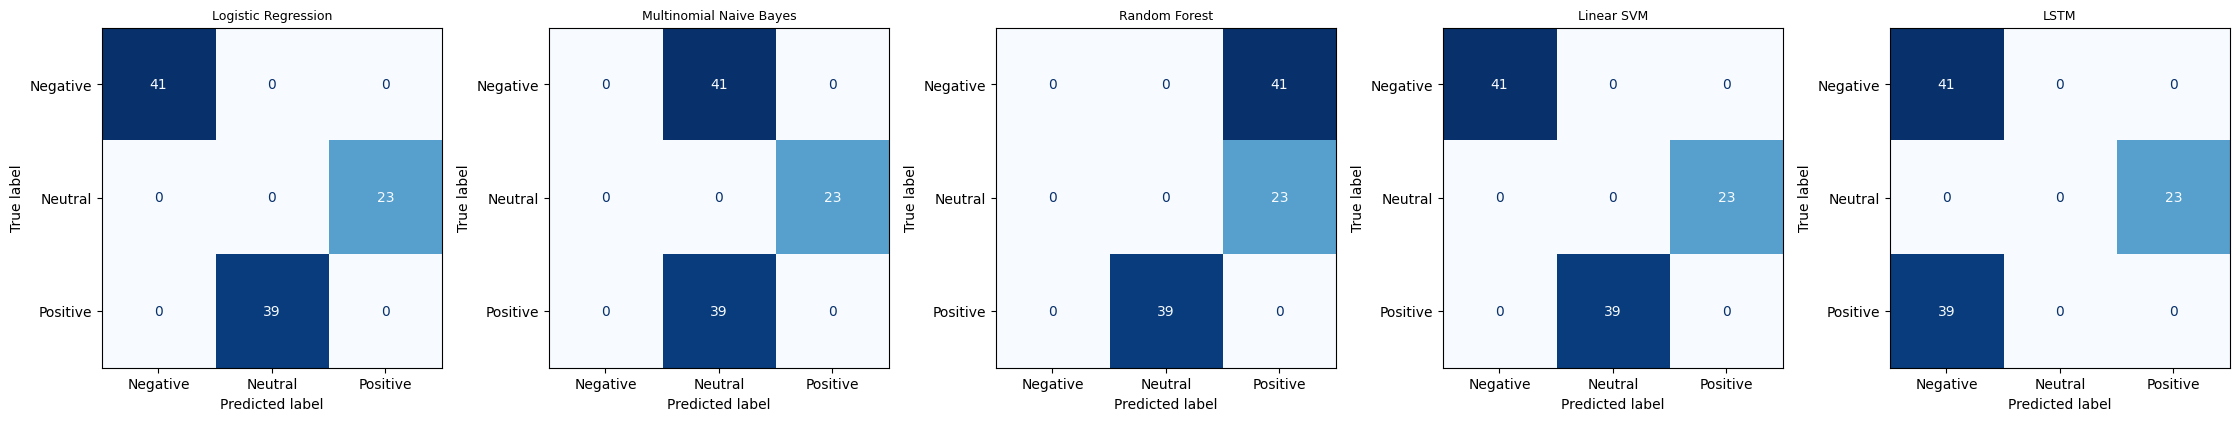

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

n = len(predictions)
fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.5))

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds, labels=labels_order)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.show()

AUC-ROC curves

In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=labels_order)
roc_results = {}

for name, model in trained_models.items():
    X_te = X_test_tfidf if name == 'Multinomial Naive Bayes' else X_test
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)
    else:
        y_score = model.decision_function(X_te)
    col_order = [list(model.classes_).index(c) for c in labels_order]
    y_score = y_score[:, col_order]
    roc_results[name] = y_score


roc_results['LSTM'] = lstm_probs

auc_scores = {}
for name, y_score in roc_results.items():
    auc_scores[name] = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
    print(f"{name}: macro AUC-ROC = {auc_scores[name]:.3f}")

Logistic Regression: macro AUC-ROC = 0.333
Multinomial Naive Bayes: macro AUC-ROC = 0.124
Random Forest: macro AUC-ROC = 0.333
Linear SVM: macro AUC-ROC = 0.547
LSTM: macro AUC-ROC = 0.124


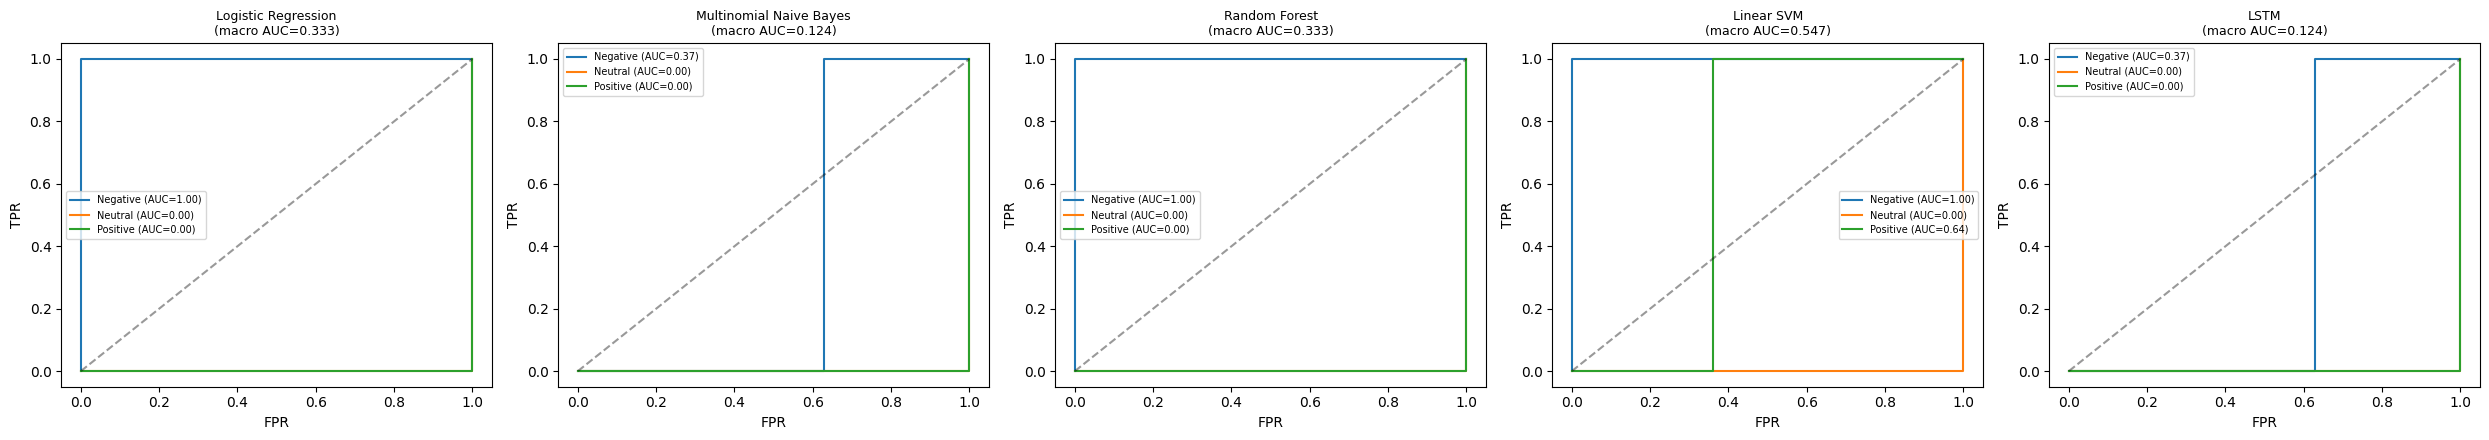

In [20]:
n = len(roc_results)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5))

for ax, (name, y_score) in zip(axes, roc_results.items()):
    for i, cls in enumerate(labels_order):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        ax.plot(fpr, tpr, label=f'{cls} (AUC={auc(fpr, tpr):.2f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_title(f'{name}\n(macro AUC={auc_scores[name]:.3f})', fontsize=9)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

Results

In [21]:
results_df['AUC (macro)'] = results_df['Model'].map(auc_scores)
results_df = results_df.sort_values(['F1 (macro)', 'AUC (macro)'], ascending=False).reset_index(drop=True)
print("Full ranking:")
results_df

Full ranking:


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),AUC (macro)
0,Linear SVM,0.398058,0.333333,0.333333,0.333333,0.546875
1,Logistic Regression,0.398058,0.333333,0.333333,0.333333,0.333333
2,LSTM,0.398058,0.170833,0.333333,0.225895,0.123656
3,Random Forest,0.000000,0.000000,0.000000,0.000000,0.333333
4,Multinomial Naive Bayes,0.000000,0.000000,0.000000,0.000000,0.123656


In [22]:
DEPLOY_MODEL_NAME = 'Linear SVM'  
print(f"Selected for deployment: {DEPLOY_MODEL_NAME}")
print(results_df[results_df['Model'] == DEPLOY_MODEL_NAME])

Selected for deployment: Linear SVM
        Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  \
0  Linear SVM  0.398058           0.333333        0.333333    0.333333   

   AUC (macro)  
0     0.546875  


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

preprocessor = ColumnTransformer(transformers=[
    ('tfidf', TfidfVectorizer(max_features=2000, ngram_range=(1, 2)), 'review_clean'),
    ('numeric', StandardScaler(), ['review_length_clean', 'clean_token_count']),
])

calibrated_svm = CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=5000), cv=3)

deploy_pipeline = Pipeline([
    ('features', preprocessor),
    ('classifier', calibrated_svm),
])

deploy_pipeline.fit(
    train_df[['review_clean', 'review_length_clean', 'clean_token_count']],
    y_train
)

joblib.dump(deploy_pipeline, 'sentiment_pipeline.joblib')
print("Linear SVM Pipeline saved: sentiment_pipeline.joblib")

Linear SVM Pipeline saved: sentiment_pipeline.joblib


VADER

In [23]:
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

test_df['vader_pred'] = test_df['review'].apply(vader_sentiment)

vader_acc = accuracy_score(y_test, test_df['vader_pred'])
deploy_acc = results_df.set_index('Model').loc[DEPLOY_MODEL_NAME, 'Accuracy']

print(f"VADER accuracy on leakage-safe test set: {vader_acc:.3f}")
print(f"{DEPLOY_MODEL_NAME} accuracy on the same test set: {deploy_acc:.3f}")

VADER accuracy on leakage-safe test set: 0.777
Linear SVM accuracy on the same test set: 0.398


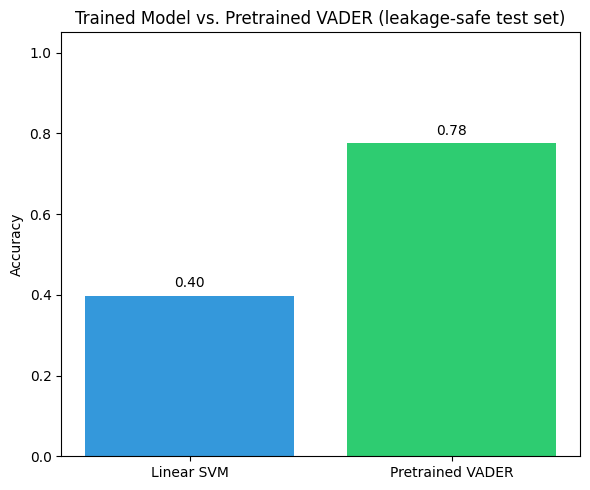

,Approach,Accuracy
0,Linear SVM,0.398058
1,Pretrained VADER,0.776699


In [24]:
comparison = pd.DataFrame({
    'Approach': [DEPLOY_MODEL_NAME, 'Pretrained VADER'],
    'Accuracy': [deploy_acc, vader_acc],
})

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(comparison['Approach'], comparison['Accuracy'], color=['#3498db', '#2ecc71'])
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.05)
ax.set_title('Trained Model vs. Pretrained VADER (leakage-safe test set)')
for bar, val in zip(bars, comparison['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}', ha='center')
plt.tight_layout()
plt.show()

comparison